# Notebook 5 — Fehleranalyse: False Negatives und False Positives (Stand C)

**Ziel:** Qualitative Diagnose der Fehlklassifikationen aus den Stand-C-Artefakten.  
Kein Modell-Training, keine Threshold-Änderung, keine Optimierung.

**Analyse 1:** False-Negative-Cases — die 3 mali-Cases, die von Log-only nicht erkannt wurden.  
**Analyse 2:** False-Positive-Cases nach Szenario — welche anom/norm-Szenarien erzeugen besonders viele FP.

**Input-Artefakte (nur lesen):**
- `docs/fusion_cases.csv` — alle 253 Test-Cases mit Scores und Triggern
- `docs/final_results_table.csv` — Thresholds und Gesamtmetriken
- `docs/log_test_scores.csv` — Log-Scores und Threshold
- `docs/metric_case_test_scores.csv` — Metrik-Scores und Threshold
- `docs/split_assignments.csv` — Split-Zuweisung aller 1.252 Cases
- Log-Dateien aus `data/{dataset_type}_dataset/{scenario_id}/` (kurze Excerpts)

**Output-Artefakte (neu):**
- `docs/false_negative_cases.csv`
- `docs/false_negative_summary.md`
- `docs/false_positive_by_scenario.csv`
- `docs/false_positive_by_scenario_top.csv`
- `docs/false_positive_scenario_summary.md`
- `docs/fp_by_scenario_logonly.png`

In [1]:
import pandas as pd
import numpy as np
import os
import re
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

# ─── Paths ────────────────────────────────────────────────────────────────────
nb_dir    = os.getcwd()                        # notebooks/
base_path = os.path.join(nb_dir, '..', 'data')
docs_path = os.path.join(nb_dir, '..', 'docs')
os.makedirs(docs_path, exist_ok=True)

# ─── Load core artefacts ──────────────────────────────────────────────────────
fusion   = pd.read_csv(os.path.join(docs_path, 'fusion_cases.csv'))
results  = pd.read_csv(os.path.join(docs_path, 'final_results_table.csv'))
log_sc   = pd.read_csv(os.path.join(docs_path, 'log_test_scores.csv'))
met_sc   = pd.read_csv(os.path.join(docs_path, 'metric_case_test_scores.csv'))
split_df = pd.read_csv(os.path.join(docs_path, 'split_assignments.csv'))

print(f'fusion_cases.csv:           {len(fusion)} rows')
print(f'final_results_table.csv:    {len(results)} rows')
print(f'log_test_scores.csv:        {len(log_sc)} rows')
print(f'metric_case_test_scores.csv:{len(met_sc)} rows')
print(f'split_assignments.csv:      {len(split_df)} rows')

fusion_cases.csv:           253 rows
final_results_table.csv:    4 rows
log_test_scores.csv:        253 rows
metric_case_test_scores.csv:253 rows
split_assignments.csv:      1252 rows


In [2]:
# ─── Extract thresholds from final_results_table ──────────────────────────────
thr_log    = float(results.loc[results['Model'] == 'Log-only',    'Threshold'].values[0])
thr_metric = float(results.loc[results['Model'] == 'Metrics-only','Threshold'].values[0])
thr_soft   = float(results.loc[results['Model'] == 'Soft-Fusion', 'Threshold'].values[0])

print(f'Threshold Log-only:    {thr_log}')
print(f'Threshold Metrics-only:{thr_metric}')
print(f'Threshold Soft-Fusion: {thr_soft}')

# Invariante Prüfungen: Log-only-Threshold unverändert (nicht neu trainiert)
assert abs(thr_log - 0.164056) < 1e-4, f'Unexpected log threshold: {thr_log}'
# Metrics-only-Threshold
assert abs(thr_metric - 0.025803) < 1e-4, f'Unexpected metric threshold: {thr_metric}'
# Soft-Fusion-Threshold
assert abs(thr_soft - 0.004785) < 1e-4, f'Unexpected soft threshold: {thr_soft}'
print('✓ Thresholds geladen')

Threshold Log-only:    0.164056
Threshold Metrics-only:0.025803
Threshold Soft-Fusion: 0.004785
✓ Thresholds geladen


In [3]:
# ─── Invarianten-Check: final_results_table ──────────────────────────────────
log_row  = results[results['Model'] == 'Log-only'].iloc[0]
soft_row = results[results['Model'] == 'Soft-Fusion'].iloc[0]
met_row  = results[results['Model'] == 'Metrics-only'].iloc[0]

# Log-only: unveraendert (nicht neu trainiert)
assert abs(float(log_row['Recall_mali']) - 0.9375) < 1e-4, 'Log Recall changed!'
assert abs(float(log_row['FPR_total'])   - 0.2537) < 1e-4, 'Log FPR changed!'
# Metrics-only: FPR unveraendert (weiterhin 1.0)
assert abs(float(met_row['FPR_total'])   - 1.0)    < 1e-4, 'Metric FPR changed!'
# Soft-Fusion: AP
assert abs(float(soft_row['AP'])         - 0.5553) < 1e-4, f'Soft AP unexpected: {float(soft_row["AP"])}'
print('✓ final_results_table.csv: Kernergebnisse unveraendert')

✓ final_results_table.csv: Kernergebnisse unveraendert


In [4]:
# ─── Reproduzierbarkeitscheck: fusion_cases.csv ↔ split_assignments.csv ────────
# Prüft, dass fusion_cases.csv exakt dem Testsplit aus split_assignments.csv
# entspricht und jede case_id nur einmal vorkommt.
test_ids   = set(split_df.loc[split_df["split"] == "test", "case_id"])
fusion_ids = set(fusion["case_id"])

assert fusion["case_id"].is_unique, "case_id in fusion_cases.csv ist nicht eindeutig!"
assert fusion_ids == test_ids, (
    f"fusion_cases.csv stimmt nicht exakt mit Testsplit überein.\n"
    f"  Nur in fusion:      {fusion_ids - test_ids}\n"
    f"  Nur in test_split:  {test_ids - fusion_ids}"
)

print(f"split_assignments.csv (split=test): {len(test_ids)} case_ids")
print(f"fusion_cases.csv:                   {len(fusion_ids)} eindeutige case_ids")
print(f"case_id ist eindeutig: {fusion['case_id'].is_unique}")
print("✓ case_id in fusion_cases.csv ist eindeutig")
print("✓ fusion_ids == test_ids: fusion_cases.csv entspricht exakt dem Testsplit")

split_assignments.csv (split=test): 253 case_ids
fusion_cases.csv:                   253 eindeutige case_ids
case_id ist eindeutig: True
✓ case_id in fusion_cases.csv ist eindeutig
✓ fusion_ids == test_ids: fusion_cases.csv entspricht exakt dem Testsplit


## Analyse 1: False-Negative-Cases (Log-only)

In [5]:
# ─── Identify FN cases: mali with log_trigger == 0 ────────────────────────────
fn_cases = fusion[
    (fusion['dataset_type'] == 'mali') & (fusion['log_trigger'] == 0)
].copy()

print(f'False-Negative Cases (Log-only): {len(fn_cases)}')
print(fn_cases[['case_id', 'scenario_id', 'log_score', 'log_trigger', 'metric_trigger']].to_string())

assert len(fn_cases) == 3, f'Expected 3 FN cases, found {len(fn_cases)}'
assert (fn_cases['dataset_type'] == 'mali').all(),  'All FN must be mali'
assert (fn_cases['label'] == 1).all(),              'All FN must have label==1'
assert (fn_cases['log_trigger'] == 0).all(),        'All FN must have log_trigger==0'
print('✓ FN assertions passed')

False-Negative Cases (Log-only): 3
          case_id scenario_id  log_score  log_trigger  metric_trigger
1   mali_6_10.csv  scenario_6   0.071899            0               1
7   mali_6_16.csv  scenario_6   0.067102            0               1
16  mali_6_24.csv  scenario_6   0.055297            0               1
✓ FN assertions passed


In [6]:
# ─── Log-Normalisierung (identisch zu NB03) ────────────────────────────────────
def normalize_log_text(text: str) -> str:
    """
    Identische Normalisierung wie in notebooks/03_log_component.ipynb.
    Reihenfolge spezifisch -> allgemein.
    """
    # 1. UUIDs
    text = re.sub(
        r'\b[0-9a-fA-F]{8}-[0-9a-fA-F]{4}-[0-9a-fA-F]{4}-[0-9a-fA-F]{4}-[0-9a-fA-F]{12}\b',
        'TOKEN_ID', text)
    # 2. Nginx-Timestamp
    text = re.sub(
        r'\[\d{1,2}/(?:Jan|Feb|Mar|Apr|May|Jun|Jul|Aug|Sep|Oct|Nov|Dec)'
        r'/\d{4}:\d{2}:\d{2}:\d{2}\s[+-]\d{4}\]',
        'TOKEN_TIME', text)
    # 3. Syslog-Timestamp
    text = re.sub(
        r'\b(?:Jan|Feb|Mar|Apr|May|Jun|Jul|Aug|Sep|Oct|Nov|Dec)'
        r'\s{1,2}\d{1,2}\s+\d{2}:\d{2}:\d{2}\b',
        'TOKEN_TIME', text)
    # 4. ISO-Timestamp mit Zeit
    text = re.sub(
        r'\d{4}[-/]\d{2}[-/]\d{2}[T ]\d{2}:\d{2}:\d{2}(?:\.\d+)?(?:Z|[+-]\d{2}:\d{2})?',
        'TOKEN_TIME', text)
    # 5. ISO-Datum
    text = re.sub(r'\d{4}[-/]\d{2}[-/]\d{2}', 'TOKEN_DATE', text)
    # 6. Uhrzeit
    text = re.sub(r'\b\d{2}:\d{2}(?::\d{2})?\b', 'TOKEN_TIME', text)
    # 7. IPv4
    text = re.sub(r'\b(?:\d{1,3}\.){3}\d{1,3}\b', 'TOKEN_IP', text)
    # 8. PIDs
    text = re.sub(r'\[(\d+)\]', '[TOKEN_PID]', text)
    # 9. Port-Keywords
    text = re.sub(r'\bport[= ]+\d+\b', 'port TOKEN_PORT', text, flags=re.IGNORECASE)
    # 10. Kolon-Port
    text = re.sub(r'(?<=[a-zA-Z]):\d{2,5}\b', ':TOKEN_PORT', text)
    # 11. Isolierte Zahlen
    text = re.sub(r'\b\d+\b', 'TOKEN_NUM', text)
    return text


def load_log_text(case_id, dataset_type, scenario_id, base_path):
    """Lädt Log-Datei einer Case (identische Logik wie NB03)."""
    log_filename = case_id.replace('.csv', '.log')
    log_path = os.path.join(base_path, f"{dataset_type}_dataset", scenario_id, log_filename)
    if os.path.exists(log_path):
        with open(log_path, 'r', encoding='utf-8', errors='ignore') as f:
            return f.read()
    return ''


ATTACK_KEYWORDS = [
    'sshd', 'accepted', 'failed', 'sudo', 'cron', 'curl', 'wget',
    'chmod', 'bash', 'command', 'login', 'root', 'webadmin',
    'reverse', 'shell', 'payload', 'password', 'exec', 'netcat',
    'python', 'perl', '/etc/', '/tmp/', 'base64', 'decode', 'nc '
]


def count_attack_keywords(text: str) -> dict:
    """Zählt Treffer der einfachen Angriffshinweis-Keywords (case-insensitive)."""
    text_lower = text.lower()
    hits = {kw: text_lower.count(kw) for kw in ATTACK_KEYWORDS if text_lower.count(kw) > 0}
    return hits


def qualitative_note(log_score, threshold, n_keyword_hits):
    """Generiert eine vorsichtig formulierte qualitative Beobachtung."""
    margin = log_score - threshold
    if margin > -0.05:
        base = 'score close to threshold'
    elif margin > -0.10:
        base = 'score moderately below threshold'
    else:
        base = 'score far below threshold, logs appear weakly indicative'

    if n_keyword_hits >= 5:
        kw_note = 'several security-relevant keyword hits (e.g. cron, sshd, root)'
    elif n_keyword_hits >= 2:
        kw_note = 'some security-relevant keyword hits'
    elif n_keyword_hits == 1:
        kw_note = 'few security-relevant keyword hits'
    else:
        kw_note = 'no keyword hits from predefined security keyword list — requires manual inspection'

    return f'{base}; {kw_note}'


print('✓ Hilfsfunktionen definiert')

✓ Hilfsfunktionen definiert


In [7]:
# ─── Log-Texte für FN-Cases laden ─────────────────────────────────────────────
fn_rows = []
for _, row in fn_cases.iterrows():
    raw_text  = load_log_text(row['case_id'], row['dataset_type'],
                               row['scenario_id'], base_path)
    norm_text = normalize_log_text(raw_text)
    kw_hits   = count_attack_keywords(raw_text)
    n_hits    = sum(kw_hits.values())

    fn_rows.append({
        'case_id':                  row['case_id'],
        'dataset_type':             row['dataset_type'],
        'scenario_id':              row['scenario_id'],
        'group_id':                 row['group_id'],
        'label':                    int(row['label']),
        'log_score':                round(float(row['log_score']),   6),
        'log_threshold':            round(thr_log,                   6),
        'log_margin_to_threshold':  round(float(row['log_score']) - thr_log, 6),
        'metric_score':             round(float(row['metric_score']), 6),
        'metric_trigger':           int(row['metric_trigger']),
        'log_trigger':              int(row['log_trigger']),
        'and_trigger':              int(row['and_trigger']),
        'score_fusion':             round(float(row['score_fusion']), 6),
        'soft_fusion_trigger':      int(row['soft_fusion_trigger']),
        'raw_log_excerpt':          raw_text[:500],
        'normalized_log_excerpt':   norm_text[:500],
        'attack_keyword_hits':      str(kw_hits),
        'qualitative_note':         qualitative_note(float(row['log_score']), thr_log, n_hits),
    })

fn_df = pd.DataFrame(fn_rows)

print('False-Negative Cases — Übersicht:')
print(fn_df[['case_id', 'scenario_id', 'log_score', 'log_threshold',
              'log_margin_to_threshold', 'qualitative_note']].to_string())

assert (fn_df['log_margin_to_threshold'] < 0).all(), 'All margins must be negative'
print('\n✓ Alle Margins negativ (log_score < threshold) — korrekt')

False-Negative Cases — Übersicht:
         case_id scenario_id  log_score  log_threshold  log_margin_to_threshold                                                                                                          qualitative_note
0  mali_6_10.csv  scenario_6   0.071899       0.164056                -0.092157                          score moderately below threshold; several security-relevant keyword hits (e.g. cron, sshd, root)
1  mali_6_16.csv  scenario_6   0.067102       0.164056                -0.096954                          score moderately below threshold; several security-relevant keyword hits (e.g. cron, sshd, root)
2  mali_6_24.csv  scenario_6   0.055297       0.164056                -0.108759  score far below threshold, logs appear weakly indicative; several security-relevant keyword hits (e.g. cron, sshd, root)

✓ Alle Margins negativ (log_score < threshold) — korrekt


In [8]:
# ─── false_negative_cases.csv speichern ───────────────────────────────────────
fn_path = os.path.join(docs_path, 'false_negative_cases.csv')
fn_df.to_csv(fn_path, index=False)
print(f'✓ docs/{os.path.basename(fn_path)} gespeichert ({len(fn_df)} Zeilen)')

✓ docs/false_negative_cases.csv gespeichert (3 Zeilen)


In [9]:
# ─── false_negative_summary.md schreiben ──────────────────────────────────────
lines = [
    '# False-Negative-Analyse: Log-only (Stand C)',
    '',
    '> Qualitative Fehleranalyse — keine neue Evaluation, keine Threshold-Änderung.',
    '',
    '## Überblick',
    '',
    f'- **Anzahl FN:** {len(fn_df)} (von 48 positiven Test-Cases)',
    f'- **Modell:** Log-only (TF-IDF + Logistic Regression, normalisiert)',
    f'- **Log-Threshold (Validation):** {thr_log}',
    f'- **Alle drei FN-Cases haben log_score < threshold.**',
    '',
    '## FN-Cases im Detail',
    '',
    '| case_id | scenario_id | log_score | threshold | margin | qualitative_note |',
    '|---|---|---|---|---|---|',
]
for _, r in fn_df.iterrows():
    lines.append(
        f"| {r['case_id']} | {r['scenario_id']} | {r['log_score']:.6f} "
        f"| {r['log_threshold']:.6f} | {r['log_margin_to_threshold']:.6f} "
        f"| {r['qualitative_note']} |"
    )

lines += [
    '',
    '## Score-Abstände zum Threshold',
    '',
]
for _, r in fn_df.iterrows():
    margin = r['log_margin_to_threshold']
    closeness = 'knapp' if abs(margin) < 0.05 else ('moderat' if abs(margin) < 0.10 else 'deutlich')
    lines.append(f"- **{r['case_id']}** (`{r['scenario_id']}`): margin = {margin:.4f} → {closeness} unter Threshold")

lines += [
    '',
    '## Erkennbare Angriffshinweise in den Log-Excerpts',
    '',
]
for _, r in fn_df.iterrows():
    lines.append(f"- **{r['case_id']}**: {r['attack_keyword_hits']}")

lines += [
    '',
    '## Fazit',
    '',
    'Die Threshold-Sensitivity-Analyse (NB03) belegt bereits, dass kein validierungsbasierter',
    'Threshold den Test-Recall auf > 0,9375 hebt: Die drei FN-Cases liegen unterhalb jedes',
    'auf dem Validierungsset bestimmbaren Thresholds. Die Scores dieser Cases liegen im',
    'niedrigen Bereich — das Modell hat für diese Cases keine ausreichend starken',
    'semantischen Muster im normalisierten Log-Text gefunden.',
    '',
    '**Methodischer Hinweis:** Diese Analyse ist rein deskriptiv. Es wurde keine',
    'testbasierte Optimierung vorgenommen. Die Ergebnisse aus `final_results_table.csv`',
    'bleiben unverändert.',
]

fn_summary_path = os.path.join(docs_path, 'false_negative_summary.md')
with open(fn_summary_path, 'w', encoding='utf-8') as f:
    f.write('\n'.join(lines))
print(f'✓ docs/{os.path.basename(fn_summary_path)} gespeichert')

✓ docs/false_negative_summary.md gespeichert


In [10]:
# ─── Malicious Test-Szenario-Recall-Tabelle (Log-only) ───────────────────────
# Kompakte Tabelle: wie hoch ist der Recall je mali-Szenario im Testset?
# Kein neues Modell, keine Threshold-Änderung — nur Auswertung bestehender Trigger.

KNOWN_SCENARIO_NAMES = {
    'mali/scenario_6': 'Rootkit / Backdoor',
    # weitere Szenarionamen nur bei sicherer Herkunft aus vorhandenen Metadaten
}

mali_cases = fusion[fusion['dataset_type'] == 'mali'].copy()

mali_scen_rows = []
for scenario_id, grp in mali_cases.groupby('scenario_id'):
    n_test  = len(grp)
    tp      = int((grp['log_trigger'] == 1).sum())
    fn      = int((grp['log_trigger'] == 0).sum())
    recall  = tp / n_test if n_test > 0 else 0.0
    scen_key  = f"mali/{scenario_id}"
    scen_name = KNOWN_SCENARIO_NAMES.get(scen_key, "")
    mali_scen_rows.append({
        'scenario_id':    scen_key,
        'scenario_name':  scen_name,
        'n_test_cases':   n_test,
        'true_positives': tp,
        'false_negatives':fn,
        'recall':         round(recall, 4),
    })

mali_scen_df = pd.DataFrame(mali_scen_rows)
print("Malicious Test-Szenario-Recall-Tabelle (Log-only, Trigger aus fusion_cases.csv):")
print(mali_scen_df.to_string(index=False))

# Assertions
assert mali_scen_df['n_test_cases'].sum()   == 48, \
    f"Expected 48 mali test cases, got {mali_scen_df['n_test_cases'].sum()}"
assert mali_scen_df['true_positives'].sum() == 45, \
    f"Expected 45 TP, got {mali_scen_df['true_positives'].sum()}"
assert mali_scen_df['false_negatives'].sum() == 3, \
    f"Expected 3 FN, got {mali_scen_df['false_negatives'].sum()}"
print('\n✓ Aggregat-Assertions: 48 mali Cases, 45 TP, 3 FN — konsistent mit Stand-C')

# ─── Export ───────────────────────────────────────────────────────────────────
mali_scen_path = os.path.join(docs_path, 'mali_test_scenario_recall.csv')
mali_scen_df.to_csv(mali_scen_path, index=False)
print(f'✓ docs/{os.path.basename(mali_scen_path)} gespeichert ({len(mali_scen_df)} Zeilen)')

Malicious Test-Szenario-Recall-Tabelle (Log-only, Trigger aus fusion_cases.csv):
    scenario_id      scenario_name  n_test_cases  true_positives  false_negatives  recall
mali/scenario_6 Rootkit / Backdoor            24              21                3   0.875
mali/scenario_7                               24              24                0   1.000

✓ Aggregat-Assertions: 48 mali Cases, 45 TP, 3 FN — konsistent mit Stand-C
✓ docs/mali_test_scenario_recall.csv gespeichert (2 Zeilen)


## Analyse 2: False Positives nach Szenario

In [11]:
# ─── Nur negative Cases (anom + norm) aus dem Test-Set ───────────────────────
neg_df = fusion[fusion['label'] == 0].copy()
print(f'Negative Test-Cases: {len(neg_df)}')
print(neg_df['dataset_type'].value_counts().to_string())

assert len(neg_df) == 205, f'Expected 205 negative cases, found {len(neg_df)}'

Negative Test-Cases: 205
dataset_type
norm    129
anom     76


In [12]:
# ─── FP-Analyse nach Szenario für alle vier Modelle ───────────────────────────
MODEL_CONFIG = [
    {'model': 'Metrics-only', 'trigger_col': 'metric_trigger', 'score_col': 'metric_score',  'threshold': thr_metric},
    {'model': 'Log-only',     'trigger_col': 'log_trigger',    'score_col': 'log_score',      'threshold': thr_log},
    {'model': 'AND-Fusion',   'trigger_col': 'and_trigger',    'score_col': 'log_score',      'threshold': thr_log},
    {'model': 'Soft-Fusion',  'trigger_col': 'soft_fusion_trigger', 'score_col': 'score_fusion', 'threshold': thr_soft},
]

fp_rows = []
for cfg in MODEL_CONFIG:
    for (dt, scen), grp in neg_df.groupby(['dataset_type', 'scenario_id']):
        n_cases  = len(grp)
        fp       = int((grp[cfg['trigger_col']] == 1).sum())
        tn       = n_cases - fp
        fpr      = fp / n_cases if n_cases > 0 else 0.0
        scores   = grp[cfg['score_col']].astype(float)
        fp_rows.append({
            'model':       cfg['model'],
            'dataset_type': dt,
            'scenario_id': scen,
            'n_cases':     n_cases,
            'false_positives': fp,
            'true_negatives':  tn,
            'fpr':         round(fpr, 4),
            'mean_score':  round(float(scores.mean()), 4),
            'median_score':round(float(scores.median()), 4),
            'max_score':   round(float(scores.max()), 4),
            'threshold':   cfg['threshold'],
        })

fp_scen_df = pd.DataFrame(fp_rows)
print(f'Rows in false_positive_by_scenario: {len(fp_scen_df)}')
print(fp_scen_df.head(8).to_string())

Rows in false_positive_by_scenario: 28


          model dataset_type  scenario_id  n_cases  false_positives  true_negatives     fpr  mean_score  median_score  max_score  threshold
0  Metrics-only         anom  scenario_13       28               28               0  1.0000      0.0266        0.0258     0.0310   0.025803
1  Metrics-only         anom  scenario_17       18               18               0  1.0000      0.0289        0.0310     0.0346   0.025803
2  Metrics-only         anom   scenario_5       30               30               0  1.0000      0.0272        0.0258     0.0372   0.025803
3  Metrics-only         norm  scenario_15       30               30               0  1.0000      0.0932        0.0258     0.6772   0.025803
4  Metrics-only         norm   scenario_4       45               45               0  1.0000      0.0296        0.0258     0.0684   0.025803
5  Metrics-only         norm   scenario_6       24               24               0  1.0000      0.0342        0.0325     0.0657   0.025803
6  Metrics-only    

In [13]:
# ─── Konsistenzprüfung gegen fpr_by_dataset_type.csv ─────────────────────────
def agg_fpr(df, model, dt):
    sub = df[(df['model'] == model) & (df['dataset_type'] == dt)]
    return float(sub['false_positives'].sum()) / float(sub['n_cases'].sum())

log_anom = agg_fpr(fp_scen_df, 'Log-only', 'anom')
log_norm  = agg_fpr(fp_scen_df, 'Log-only', 'norm')

print(f'Log-only FPR_anom (aggregiert): {log_anom:.4f}  (erwartet: 0.2368)')
print(f'Log-only FPR_norm (aggregiert): {log_norm:.4f}  (erwartet: 0.2636)')

assert abs(log_anom - 0.2368) < 0.001, f'FPR_anom inconsistent: {log_anom}'
assert abs(log_norm - 0.2636) < 0.001, f'FPR_norm inconsistent: {log_norm}'
print('\u2713 FPR-Aggregation konsistent mit Stand-C (fpr_by_dataset_type.csv)')

Log-only FPR_anom (aggregiert): 0.2368  (erwartet: 0.2368)
Log-only FPR_norm (aggregiert): 0.2636  (erwartet: 0.2636)
✓ FPR-Aggregation konsistent mit Stand-C (fpr_by_dataset_type.csv)


In [14]:
# ─── false_positive_by_scenario.csv speichern ─────────────────────────────────
fp_out = os.path.join(docs_path, 'false_positive_by_scenario.csv')
fp_scen_df.to_csv(fp_out, index=False)
print(f'✓ docs/{os.path.basename(fp_out)} gespeichert')

# ─── false_positive_by_scenario_top.csv — sortiert nach fpr desc ──────────────
fp_top_df = (
    fp_scen_df
    .sort_values(['model', 'fpr', 'false_positives', 'n_cases'],
                 ascending=[True, False, False, False])
    .reset_index(drop=True)
)
fp_top_out = os.path.join(docs_path, 'false_positive_by_scenario_top.csv')
fp_top_df.to_csv(fp_top_out, index=False)
print(f'✓ docs/{os.path.basename(fp_top_out)} gespeichert')

✓ docs/false_positive_by_scenario.csv gespeichert


✓ docs/false_positive_by_scenario_top.csv gespeichert


In [15]:
# ─── Top 5 anom / Top 5 norm Szenarien für Log-only ──────────────────────────
log_only = fp_scen_df[fp_scen_df['model'] == 'Log-only'].copy()

top5_anom = (
    log_only[log_only['dataset_type'] == 'anom']
    .sort_values(['fpr', 'false_positives'], ascending=[False, False])
    .head(5)
)
top5_norm = (
    log_only[log_only['dataset_type'] == 'norm']
    .sort_values(['fpr', 'false_positives'], ascending=[False, False])
    .head(5)
)

print('Top 5 anom-Szenarien (Log-only):')
print(top5_anom[['scenario_id','n_cases','false_positives','fpr','mean_score']].to_string(index=False))
print()
print('Top 5 norm-Szenarien (Log-only):')
print(top5_norm[['scenario_id','n_cases','false_positives','fpr','mean_score']].to_string(index=False))

Top 5 anom-Szenarien (Log-only):


scenario_id  n_cases  false_positives    fpr  mean_score
scenario_17       18               11 0.6111      0.3218
 scenario_5       30                6 0.2000      0.1405
scenario_13       28                1 0.0357      0.0937



Top 5 norm-Szenarien (Log-only):
scenario_id  n_cases  false_positives    fpr  mean_score
 scenario_8       30               30 1.0000      0.5226
scenario_15       30                2 0.0667      0.0861
 scenario_6       24                1 0.0417      0.0717
 scenario_4       45                1 0.0222      0.0534


In [16]:
# ─── false_positive_scenario_summary.md ──────────────────────────────────────
def scenario_table_md(df):
    lines = ['| scenario_id | n_cases | FP | FPR | mean_score |',
             '|---|---|---|---|---|']
    for _, r in df.iterrows():
        lines.append(
            f"| {r['scenario_id']} | {r['n_cases']} | {r['false_positives']} "
            f"| {r['fpr']:.4f} | {r['mean_score']:.4f} |"
        )
    return '\n'.join(lines)


anom_more = 'norm' if log_norm > log_anom else 'anom'
diff      = abs(log_norm - log_anom)

fp_summary_lines = [
    '# False-Positive-Analyse nach Szenario (Stand C)',
    '',
    '> Qualitative Fehleranalyse — keine neue Evaluation, keine Threshold-Änderung.',
    '',
    '## Überblick: Aggregierte FPR (Log-only)',
    '',
    f'- **FPR_anom (Log-only):** {log_anom:.4f}  (18 / 76 anom-Cases)',
    f'- **FPR_norm (Log-only):** {log_norm:.4f}  (34 / 129 norm-Cases)',
    f'- {anom_more.capitalize()}-Fälle haben eine höhere aggregierte FPR (Δ = {diff:.4f}).',
    f'- Beide Typen werden in ähnlichem Ausmaß fehlklassifiziert; norm hat mehr absolute FP (34 vs. 18)',
    f'  wegen der größeren Grundmenge.',
    '',
    '## Top 5 anom-Szenarien mit höchster FPR (Log-only)',
    '',
    scenario_table_md(top5_anom),
    '',
    '## Top 5 norm-Szenarien mit höchster FPR (Log-only)',
    '',
    scenario_table_md(top5_norm),
    '',
    '## Interpretation',
    '',
    '- Szenarien mit FPR = 1.0 (alle Cases des Szenarios fälschlich positiv) deuten auf',
    '  Log-Muster hin, die dem Modell verdaechtig erscheinen, obwohl kein Angriff vorliegt.',
    '- Bei anom-Szenarien kann dies an technischen Anomalien mit ähnlichen Prozessaufrufen',
    '  wie bei Malware liegen (z.B. häufige SSH-Events, Cronjobs, Skriptausführungen).',
    '- Bei norm-Szenarien sind ressourcenintensive Backup- oder Batch-Prozesse typische',
    '  Kandidaten für Log-Muster mit oberflächlicher Ähnlichkeit zu Angriffsmustern.',
    '- Metrics-only hat in allen anom/norm-Szenarien FPR = 1.0 (triviales Ergebnis,',
    '  da metric_trigger=1 für alle 253 Cases).',
    '',
    '**Methodischer Hinweis:** Diese Analyse ist rein deskriptiv. Die Zahlen in',
    '`final_results_table.csv` wurden nicht verändert.',
]

fp_summary_path = os.path.join(docs_path, 'false_positive_scenario_summary.md')
with open(fp_summary_path, 'w', encoding='utf-8') as f:
    f.write('\n'.join(fp_summary_lines))
print(f'✓ docs/{os.path.basename(fp_summary_path)} gespeichert')

✓ docs/false_positive_scenario_summary.md gespeichert


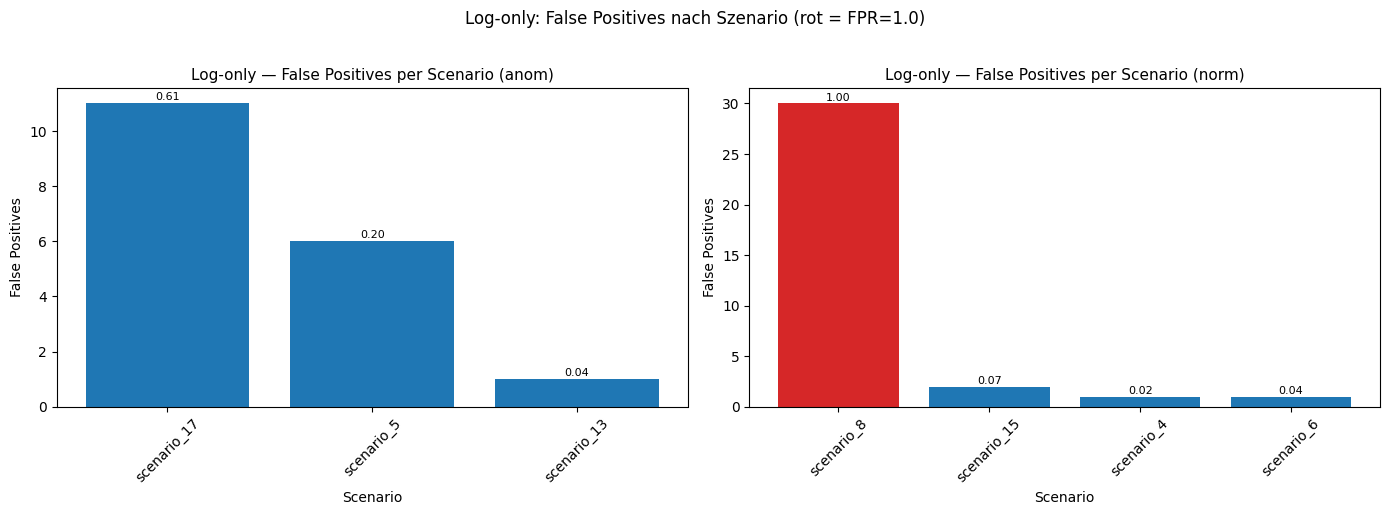

✓ docs/fp_by_scenario_logonly.png gespeichert


In [17]:
# ─── Balkenplot: FP-Szenarien Log-only ────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, (dt, title_dt) in zip(axes, [('anom', 'anom'), ('norm', 'norm')]):
    sub = (
        log_only[log_only['dataset_type'] == dt]
        .sort_values('false_positives', ascending=False)
        .head(10)
    )
    colors = ['#d62728' if fpr >= 1.0 else '#1f77b4' for fpr in sub['fpr']]
    bars = ax.bar(sub['scenario_id'], sub['false_positives'], color=colors)
    ax.set_title(f'Log-only — False Positives per Scenario ({title_dt})', fontsize=11)
    ax.set_xlabel('Scenario')
    ax.set_ylabel('False Positives')
    ax.tick_params(axis='x', rotation=45)
    # Annotate with FPR
    for bar, (_, row) in zip(bars, sub.iterrows()):
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 0.05,
            f'{row["fpr"]:.2f}',
            ha='center', va='bottom', fontsize=8
        )

plt.suptitle(
    'Log-only: False Positives nach Szenario (rot = FPR=1.0)',
    fontsize=12, y=1.02
)
plt.tight_layout()
plot_path = os.path.join(docs_path, 'fp_by_scenario_logonly.png')
plt.savefig(plot_path, dpi=150, bbox_inches='tight')
plt.show()
print(f'✓ docs/{os.path.basename(plot_path)} gespeichert')

In [18]:
# ─── Finale Zusammenfassung ───────────────────────────────────────────────────
print('=' * 60)
print('FEHLERANALYSE ABGESCHLOSSEN')
print('=' * 60)
print()
print(f'Analyse 1 — False Negatives (Log-only):')
print(f'  FN-Cases: {len(fn_df)}')
for _, r in fn_df.iterrows():
    print(f'  {r["case_id"]:30s}  log_score={r["log_score"]:.4f}  margin={r["log_margin_to_threshold"]:.4f}')
print()
print(f'Analyse 2 — False Positives nach Szenario:')
print(f'  Log-only FPR_anom = {log_anom:.4f}  |  FPR_norm = {log_norm:.4f}')
print()
print('Erzeugte Artefakte:')
for fname in [
    'false_negative_cases.csv',
    'false_negative_summary.md',
    'false_positive_by_scenario.csv',
    'false_positive_by_scenario_top.csv',
    'false_positive_scenario_summary.md',
    'fp_by_scenario_logonly.png',
]:
    p = os.path.join(docs_path, fname)
    exists = os.path.exists(p)
    print(f'  {"✓" if exists else "✗"} docs/{fname}')
print()
print('Kein Modell trainiert. Keine Thresholds geändert.')
print('final_results_table.csv bleibt unverändert.')

FEHLERANALYSE ABGESCHLOSSEN

Analyse 1 — False Negatives (Log-only):
  FN-Cases: 3
  mali_6_10.csv                   log_score=0.0719  margin=-0.0922
  mali_6_16.csv                   log_score=0.0671  margin=-0.0970
  mali_6_24.csv                   log_score=0.0553  margin=-0.1088

Analyse 2 — False Positives nach Szenario:
  Log-only FPR_anom = 0.2368  |  FPR_norm = 0.2636

Erzeugte Artefakte:
  ✓ docs/false_negative_cases.csv
  ✓ docs/false_negative_summary.md
  ✓ docs/false_positive_by_scenario.csv
  ✓ docs/false_positive_by_scenario_top.csv
  ✓ docs/false_positive_scenario_summary.md
  ✓ docs/fp_by_scenario_logonly.png

Kein Modell trainiert. Keine Thresholds geändert.
final_results_table.csv bleibt unverändert.
